# Technical Indicator Interpretation

## Moving Averages (SMA and EMA)

The moving averages highlighted overall stock trends across the analyzed companies. EMA reacted more quickly to recent price changes compared to SMA, making it more responsive to short-term market fluctuations.

## RSI

RSI values helped identify periods of overbought and oversold market conditions. Several stocks experienced RSI values above 70 during bullish periods.

## MACD

MACD crossovers indicated multiple momentum shifts and potential trend reversals throughout the observed trading periods.

## Daily Returns

Daily percentage returns revealed stock volatility patterns and will later be used for sentiment correlation analysis in Task 3.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from src.data_loader import load_news_data
from src.sentiment_analysis import calculate_sentiment

In [3]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\YOGA
[nltk_data]     9I\AppData\Roaming\nltk_data...


True

In [3]:
news_df = load_news_data(
    "../data/raw/raw_analyst_ratings.csv"
)

In [4]:
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


In [5]:
news_df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [6]:
news_df = news_df.drop(
    columns=['Unnamed: 0']
)

In [7]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype              
---  ------     --------------    -----              
 0   headline   1407328 non-null  str                
 1   url        1407328 non-null  str                
 2   publisher  1407328 non-null  str                
 3   date       55987 non-null    datetime64[us, UTC]
 4   stock      1407328 non-null  str                
dtypes: datetime64[us, UTC](1), str(4)
memory usage: 53.7 MB


In [8]:
news_df.isnull().sum()

headline           0
url                0
publisher          0
date         1351341
stock              0
dtype: int64

In [9]:
target_stocks = [
    'AAPL',
    'AMZN',
    'META',
    'NVDA',
    'GOOG'
]

news_df = news_df[
    news_df['stock'].isin(target_stocks)
]

In [10]:
news_df['stock'].value_counts()

stock
NVDA    3146
GOOG    1199
AAPL     441
AMZN     278
Name: count, dtype: int64

In [11]:
news_df['sentiment_score'] = (
    news_df['headline']
    .apply(calculate_sentiment)
)

In [12]:
news_df[
    ['headline', 'sentiment_score']
].head()

,headline,sentiment_score
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.5574
6681,10 Biggest Price Target Changes For Wednesday,0.0000
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.0000
6684,Apple To Let Users Trade In Their Mac Computer...,0.3818


In [23]:
news_df['date'] = pd.to_datetime(
    news_df['date']
)

news_df['date'] = (
    news_df['date']
    + pd.offsets.BDay(0)
)

news_df['date'] = (
    news_df['date']
    .dt.date
)

In [24]:
daily_sentiment = (
    news_df
    .groupby(['stock', 'date'])['sentiment_score']
    .mean()
    .reset_index()
)

In [25]:
daily_sentiment.head()

,stock,date,sentiment_score
0,AAPL,2020-06-09,0.246900
1,AAPL,2020-06-10,0.198850
2,AMZN,2020-06-09,0.077775
3,AMZN,2020-06-10,0.391233
4,GOOG,2020-06-04,0.000000


In [26]:
stocks = {
    "AAPL": "../data/processed/AAPL_processed.csv",
    "AMZN": "../data/processed/AMZN_processed.csv",
    "NVDA": "../data/processed/NVDA_processed.csv",
    "GOOG": "../data/processed/GOOG_processed.csv"
}

Analyzing AAPL
Correlation: 1.0000
P-value: 1.0000


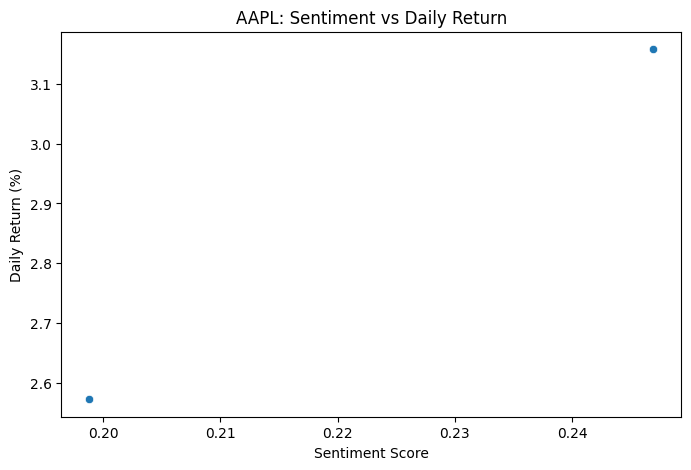

Analyzing AMZN
Correlation: -1.0000
P-value: 1.0000


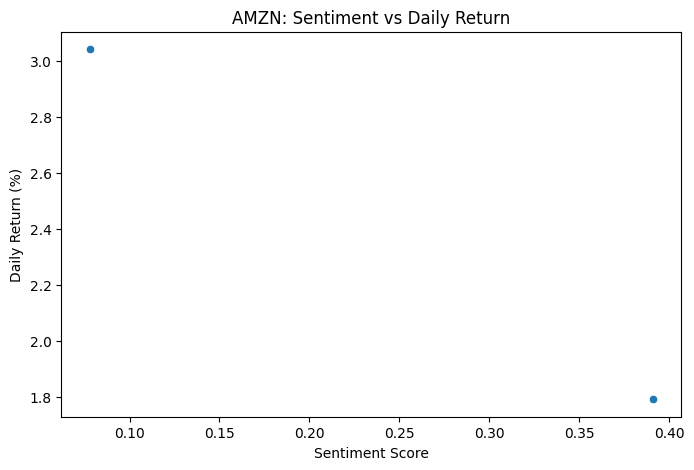

Analyzing NVDA
Correlation: 0.3965
P-value: 0.5087


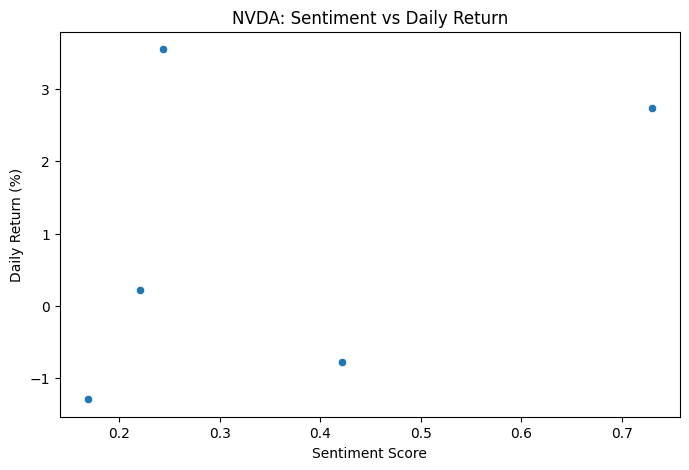

Analyzing GOOG
Correlation: -0.2344
P-value: 0.7044


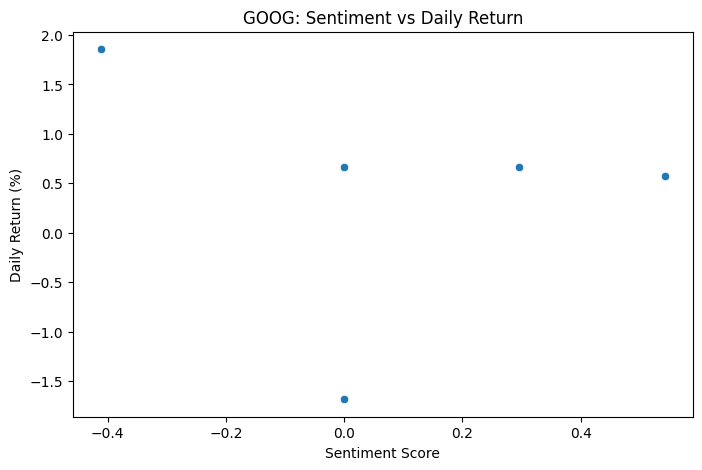

In [27]:
all_results = []

for stock_symbol, file_path in stocks.items():

    print("=" * 60)
    print(f"Analyzing {stock_symbol}")
    print("=" * 60)

    stock_df = pd.read_csv(file_path)

    stock_df['Date'] = pd.to_datetime(
        stock_df['Date']
    ).dt.date

    stock_sentiment = daily_sentiment[
        daily_sentiment['stock'] == stock_symbol
    ]

    merged_df = pd.merge(
        stock_sentiment,
        stock_df,
        left_on='date',
        right_on='Date',
        how='inner'
    )

    merged_df = merged_df.dropna(
        subset=['Daily_Return']
    )

    correlation, p_value = pearsonr(
        merged_df['sentiment_score'],
        merged_df['Daily_Return']
    )

    print(f"Correlation: {correlation:.4f}")
    print(f"P-value: {p_value:.4f}")

    all_results.append({
        'Stock': stock_symbol,
        'Correlation': correlation,
        'P-Value': p_value
    })

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x='sentiment_score',
        y='Daily_Return',
        data=merged_df
    )

    plt.title(
        f"{stock_symbol}: Sentiment vs Daily Return"
    )

    plt.xlabel("Sentiment Score")

    plt.ylabel("Daily Return (%)")

    plt.show()

In [28]:
results_df = pd.DataFrame(all_results)

results_df

,Stock,Correlation,P-Value
0,AAPL,1.000000,1.000000
1,AMZN,-1.000000,1.000000
2,NVDA,0.396518,0.508698
3,GOOG,-0.234365,0.704352


In [29]:
def classify_sentiment(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"

In [30]:
news_df['sentiment_category'] = (
    news_df['sentiment_score']
    .apply(classify_sentiment)
)

Sentiment Category Analysis: AAPL
sentiment_category
Positive    2.865281
Name: Daily_Return, dtype: float64


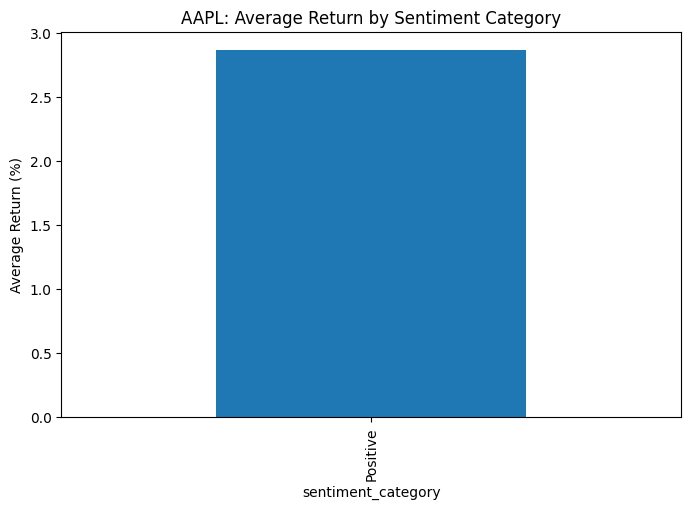

Sentiment Category Analysis: AMZN
sentiment_category
Positive    2.417022
Name: Daily_Return, dtype: float64


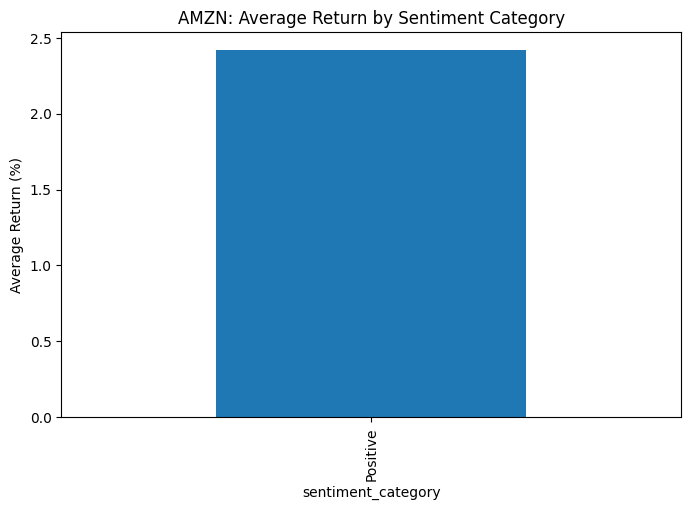

Sentiment Category Analysis: NVDA
sentiment_category
Positive    0.885825
Name: Daily_Return, dtype: float64


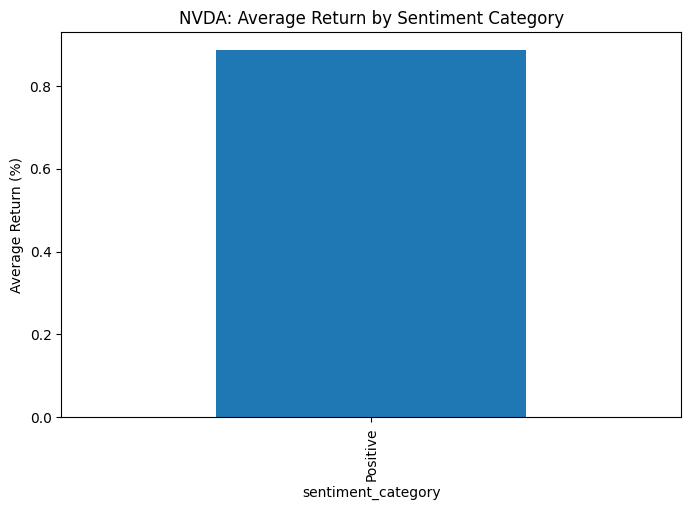

Sentiment Category Analysis: GOOG
sentiment_category
Negative    1.855992
Neutral    -0.512320
Positive    0.618470
Name: Daily_Return, dtype: float64


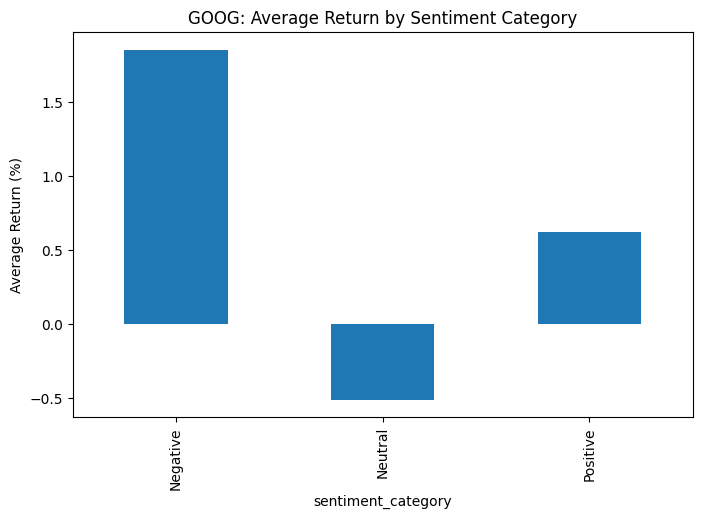

In [ ]:
for stock_symbol, file_path in stocks.items():

    print("=" * 60)
    print(f"Sentiment Category Analysis: {stock_symbol}")
    print("=" * 60)

    stock_df = pd.read_csv(file_path)

    stock_df['Date'] = pd.to_datetime(
        stock_df['Date']
    ).dt.date

    stock_sentiment = daily_sentiment[
        daily_sentiment['stock'] == stock_symbol
    ]

    # Merge datasets
    merged_df = pd.merge(
        stock_sentiment,
        stock_df,
        left_on='date',
        right_on='Date',
        how='inner'
    )

    merged_df = merged_df.dropna(
        subset=['Daily_Return']
    )

    merged_df['sentiment_category'] = (
        merged_df['sentiment_score']
        .apply(classify_sentiment)
    )

    category_returns = (
        merged_df
        .groupby('sentiment_category')['Daily_Return']
        .mean()
    )

    print(category_returns)

    category_returns.plot(
        kind='bar',
        figsize=(8,5)
    )

    plt.title(
        f"{stock_symbol}: Average Return by Sentiment Category"
    )

    plt.ylabel("Average Return (%)")

    plt.show()